In [8]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import (
    Input, Dense, GlobalAveragePooling2D, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)


In [9]:
CONFIG = {
    "dataset_dir": "dr-data_variantB_green_circle_224",
    "img_size": 224,
    "num_classes": 5,
    "batch_size": 16,
    "epochs_phase1": 10,
    "epochs_phase2": 20,
    "seed": 42
}

TRAIN_DIR = os.path.join(CONFIG["dataset_dir"], "train")
VAL_DIR   = os.path.join(CONFIG["dataset_dir"], "val")
TEST_DIR  = os.path.join(CONFIG["dataset_dir"], "test")

tf.random.set_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])


In [10]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    horizontal_flip=True,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(CONFIG["img_size"], CONFIG["img_size"]),
    batch_size=CONFIG["batch_size"],
    class_mode="categorical",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(CONFIG["img_size"], CONFIG["img_size"]),
    batch_size=CONFIG["batch_size"],
    class_mode="categorical",
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(CONFIG["img_size"], CONFIG["img_size"]),
    batch_size=CONFIG["batch_size"],
    class_mode="categorical",
    shuffle=False
)

print("Class mapping:", train_gen.class_indices)


Found 64654 images belonging to 5 classes.
Found 13855 images belonging to 5 classes.
Found 13855 images belonging to 5 classes.
Class mapping: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}


In [11]:
def build_resnet50(img_size, num_classes):
    inputs = Input(shape=(img_size, img_size, 3))

    base_model = ResNet50(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs
    )

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)

    return model, base_model


In [12]:
callbacks = [
    ModelCheckpoint(
        "resnet50_variantB_best.weights.h5",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]


In [6]:
model, base_model = build_resnet50(
    CONFIG["img_size"],
    CONFIG["num_classes"]
)

for layer in base_model.layers:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

history_phase1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=CONFIG["epochs_phase1"],
    callbacks=callbacks
)


I0000 00:00:1767548999.446818 2923374 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-01-04 18:49:59.521338: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,597,957 (90.02 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.7057 - loss: 0.9323
Epoch 1: val_loss improved from None to 0.80637, saving model to resnet50_variantB_best.weights.h5
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 1045s 258ms/step - accuracy: 0.7178 - loss: 0.8801 - val_accuracy: 0.7414 - val_loss: 0.8064 - learning_rate: 0.0010
Epoch 2/10
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.7230 - loss: 0.8559
Epoch 2: val_loss improved from 0.80637 to 0.75991, saving model to resnet50_variantB_best.weights.h5
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 1041s 257ms/step - accuracy: 0.7242 - loss: 0.8517 - val_accuracy: 0.7473 - val_loss: 0.7599 - learning_rate: 0.0010
Epoch 3/10
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.7222 - loss: 0.8507
Epoch 3: val_loss improved from 0.75991 to 0.75704, saving model to resnet50_variantB_best.weights.h5
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 1048s 259ms/step - accuracy: 0.7237 - loss: 0.8525 - val_accuracy: 0.7465 - val_loss: 0.7570 - learn

In [13]:
# Unfreeze last 30 layers of ResNet50
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_phase2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=CONFIG["epochs_phase2"],
    callbacks=callbacks
)


Epoch 1/20
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.7794 - loss: 0.6613
Epoch 1: val_loss improved from None to 0.70151, saving model to resnet50_variantB_best.weights.h5
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 1575s 388ms/step - accuracy: 0.7792 - loss: 0.6613 - val_accuracy: 0.7766 - val_loss: 0.7015 - learning_rate: 1.0000e-04
Epoch 2/20
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.7852 - loss: 0.6415
Epoch 2: val_loss improved from 0.70151 to 0.67916, saving model to resnet50_variantB_best.weights.h5
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 1547s 383ms/step - accuracy: 0.7866 - loss: 0.6375 - val_accuracy: 0.7792 - val_loss: 0.6792 - learning_rate: 1.0000e-04
Epoch 3/20
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.7938 - loss: 0.6168
Epoch 3: val_loss improved from 0.67916 to 0.66613, saving model to resnet50_variantB_best.weights.h5
4041/4041 ━━━━━━━━━━━━━━━━━━━━ 1530s 379ms/step - accuracy: 0.7921 - loss: 0.6218 - val_accuracy: 0.7860 - val_loss: 0.6661

In [14]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.4f}")


866/866 ━━━━━━━━━━━━━━━━━━━━ 188s 217ms/step - accuracy: 0.7947 - loss: 0.6425
Test Accuracy: 0.7947


In [15]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = test_gen.classes
y_pred = np.argmax(model.predict(test_gen), axis=1)

print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))


866/866 ━━━━━━━━━━━━━━━━━━━━ 187s 215ms/step
              precision    recall  f1-score   support

           0       0.82      0.98      0.89     10073
           1       0.53      0.02      0.04       986
           2       0.62      0.42      0.50      2123
           3       0.58      0.24      0.34       342
           4       0.79      0.42      0.55       331

    accuracy                           0.79     13855
   macro avg       0.67      0.42      0.46     13855
weighted avg       0.76      0.79      0.75     13855

[[9882    3  178    2    8]
 [ 895   19   70    2    0]
 [1173   10  890   34   16]
 [  57    0  191   82   12]
 [  62    4  106   21  138]]


In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Predict on test set
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())


866/866 ━━━━━━━━━━━━━━━━━━━━ 189s 219ms/step


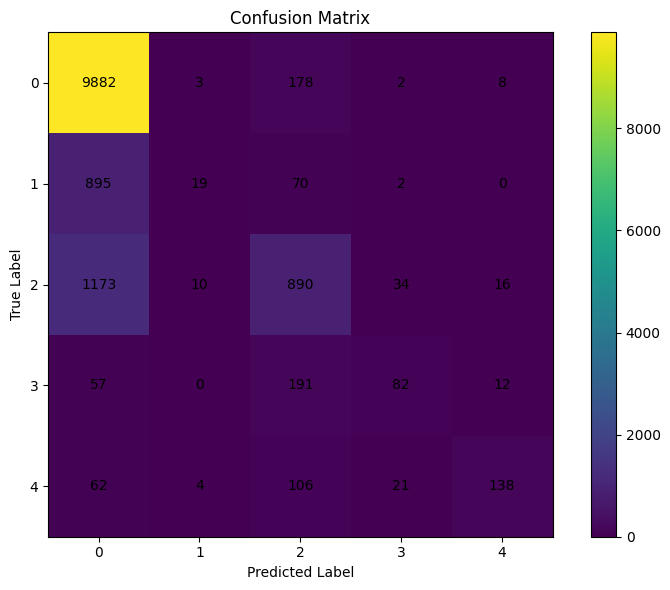

In [19]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.tight_layout()
plt.show()


In [24]:
from sklearn.metrics import cohen_kappa_score
import numpy as np

y_pred = np.argmax(model.predict(test_gen), axis=1)
y_true = test_gen.classes

kappa = cohen_kappa_score(y_true, y_pred, weights="quadratic")
print(f"Quadratic Weighted Kappa (QWK): {kappa:.4f}")


866/866 ━━━━━━━━━━━━━━━━━━━━ 181s 208ms/step
Quadratic Weighted Kappa (QWK): 0.6209


In [27]:
def combine_histories(h1, h2):
    combined = {}
    for k in h1.history.keys():
        combined[k] = h1.history[k] + h2.history[k]
    return combined

full_history = combine_histories(history_phase1, history_phase2)

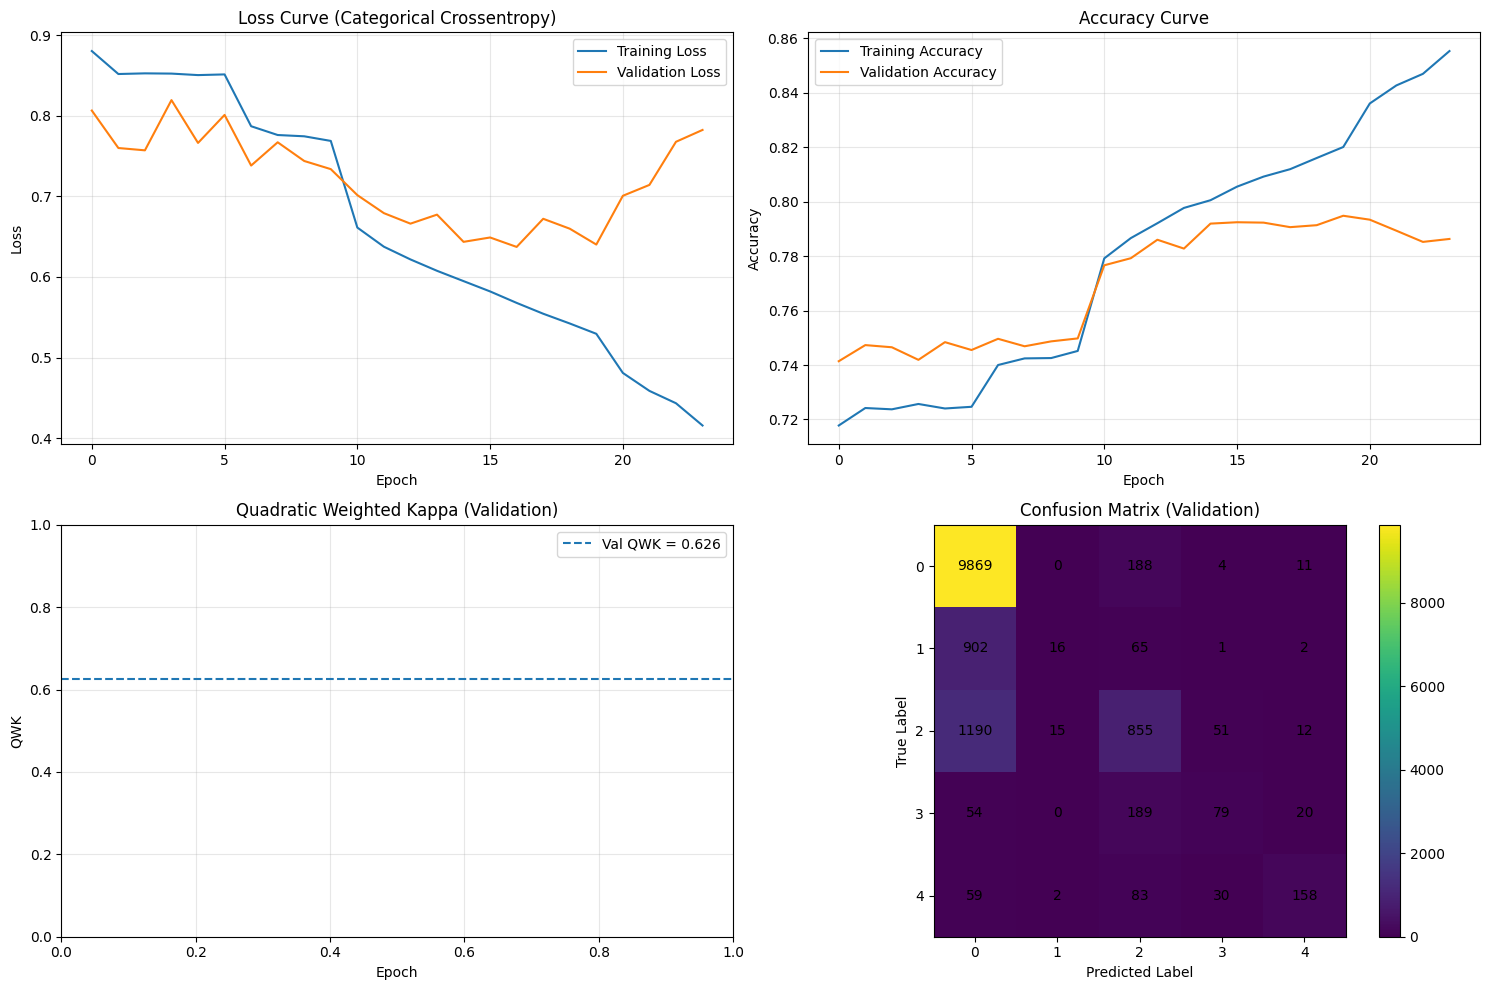

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# If you used Phase 1 + Phase 2
hist = full_history
epochs = range(len(hist["loss"]))


# If you only trained one phase, use:
# hist = history_phase2.history

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(epochs, hist["loss"], label="Training Loss")
plt.plot(epochs, hist["val_loss"], label="Validation Loss")
plt.title("Loss Curve (Categorical Crossentropy)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(epochs, hist["accuracy"], label="Training Accuracy")
plt.plot(epochs, hist["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

from sklearn.metrics import cohen_kappa_score

# Compute QWK on validation set
val_preds = np.argmax(model.predict(val_gen, verbose=0), axis=1)
val_true = val_gen.classes

qwk = cohen_kappa_score(val_true, val_preds, weights="quadratic")

plt.subplot(2, 2, 3)
plt.axhline(qwk, linestyle="--", label=f"Val QWK = {qwk:.3f}")
plt.title("Quadratic Weighted Kappa (Validation)")
plt.xlabel("Epoch")
plt.ylabel("QWK")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)

y_pred = np.argmax(model.predict(val_gen, verbose=0), axis=1)
y_true = val_gen.classes
class_names = list(val_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.subplot(2, 2, 4)
plt.imshow(cm)
plt.title("Confusion Matrix (Validation)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()

# Annotate cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


⏳ Getting softmax predictions...


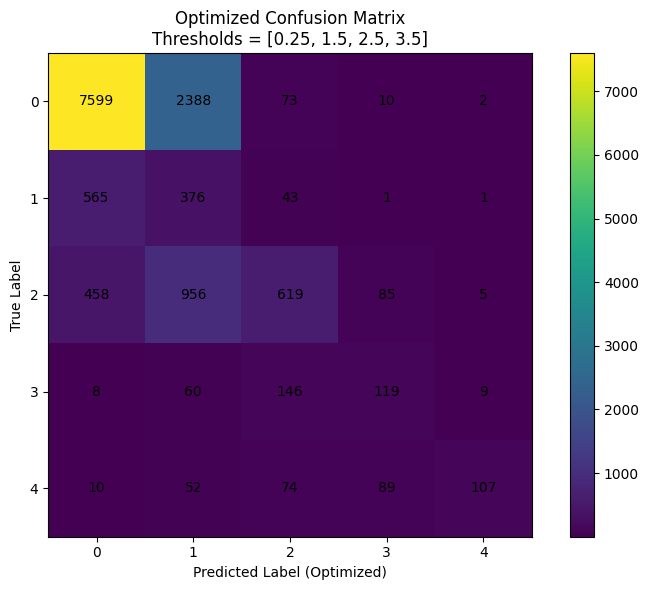

⚠️ Dangerous Misses (Grade 4 predicted as 0): 10
✅ Optimized QWK: 0.6521


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, cohen_kappa_score

print("⏳ Getting softmax predictions...")
probs = model.predict(val_gen, verbose=0)   # (N, 5)

# Class indices: [0,1,2,3,4]
class_indices = np.arange(5)

# Expected severity score
raw_scores = np.sum(probs * class_indices, axis=1)

true_labels = val_gen.classes

thresholds = [0.25, 1.5, 2.5, 3.5]

def apply_thresholds(scores, th):
    preds = np.zeros_like(scores, dtype=int)
    preds[(scores >= th[0]) & (scores < th[1])] = 1
    preds[(scores >= th[1]) & (scores < th[2])] = 2
    preds[(scores >= th[2]) & (scores < th[3])] = 3
    preds[scores >= th[3]] = 4
    return preds

optimized_preds = apply_thresholds(raw_scores, thresholds)

cm = confusion_matrix(true_labels, optimized_preds)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title(f"Optimized Confusion Matrix\nThresholds = {thresholds}")
plt.xlabel("Predicted Label (Optimized)")
plt.ylabel("True Label")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

dangerous_misses = cm[4, 0]
print(f"⚠️ Dangerous Misses (Grade 4 predicted as 0): {dangerous_misses}")

qwk_optimized = cohen_kappa_score(
    true_labels,
    optimized_preds,
    weights="quadratic"
)

print(f"✅ Optimized QWK: {qwk_optimized:.4f}")


⏳ Getting softmax predictions...
🔄 Searching for the 'Golden Thresholds'...

🏆 BEST RESULT FOUND
Max QWK: 0.6848
Best Thresholds: [0.39999999999999997, 1.3, 2.2, 3.1]


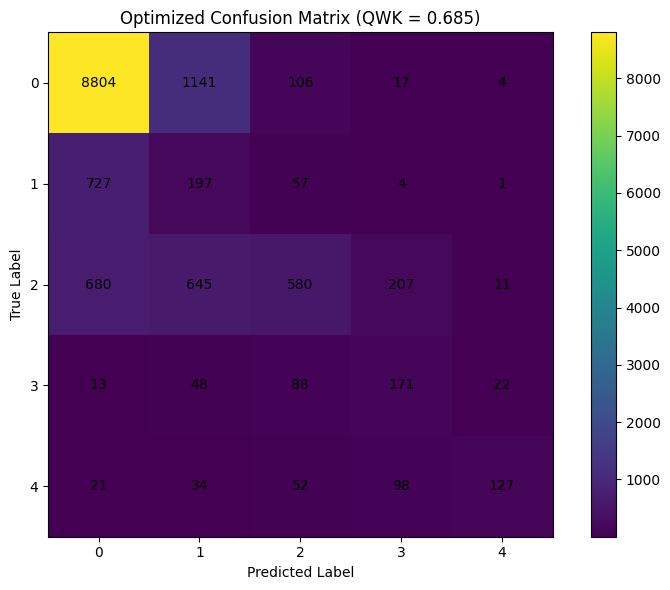

⚠️ Dangerous Misses (Class 4 → 0): 21


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score, confusion_matrix

print("⏳ Getting softmax predictions...")
probs = model.predict(val_gen, verbose=0)   # shape: (N, 5)

# Convert to continuous severity score (EXPECTED VALUE)
class_ids = np.arange(5)
raw_scores = np.sum(probs * class_ids, axis=1)

# True labels
true_labels = val_gen.classes

def get_kappa(thresholds, scores, targets):
    preds = np.zeros_like(scores, dtype=int)
    preds[(scores >= thresholds[0]) & (scores < thresholds[1])] = 1
    preds[(scores >= thresholds[1]) & (scores < thresholds[2])] = 2
    preds[(scores >= thresholds[2]) & (scores < thresholds[3])] = 3
    preds[scores >= thresholds[3]] = 4

    return cohen_kappa_score(targets, preds, weights="quadratic")

print("🔄 Searching for the 'Golden Thresholds'...")

best_kappa = -1
best_thr = None

for t0 in np.arange(0.2, 0.6, 0.05):
    for t1 in np.arange(1.3, 1.7, 0.1):
        for t2 in np.arange(2.2, 2.6, 0.1):
            for t3 in np.arange(3.1, 3.6, 0.1):

                thr = [t0, t1, t2, t3]

                # Ensure logical ordering
                if not (t0 < t1 < t2 < t3):
                    continue

                score = get_kappa(thr, raw_scores, true_labels)

                if score > best_kappa:
                    best_kappa = score
                    best_thr = thr

print("\n🏆 BEST RESULT FOUND")
print(f"Max QWK: {best_kappa:.4f}")
print(f"Best Thresholds: {best_thr}")

final_preds = np.zeros_like(raw_scores, dtype=int)
final_preds[(raw_scores >= best_thr[0]) & (raw_scores < best_thr[1])] = 1
final_preds[(raw_scores >= best_thr[1]) & (raw_scores < best_thr[2])] = 2
final_preds[(raw_scores >= best_thr[2]) & (raw_scores < best_thr[3])] = 3
final_preds[raw_scores >= best_thr[3]] = 4

cm = confusion_matrix(true_labels, final_preds)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title(f"Optimized Confusion Matrix (QWK = {best_kappa:.3f})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

print(f"⚠️ Dangerous Misses (Class 4 → 0): {cm[4, 0]}")



In [ ]:
import os

model.save("final_dr_model_v1.keras")
print("✅ Final model saved as 'final_dr_model_v1.keras'")

def check_file(filename):
    if os.path.exists(filename):
        size_mb = os.path.getsize(filename) / (1024 * 1024)
        print(f"📁 FOUND: {filename} ({size_mb:.2f} MB)")
    else:
        print(f"❌ MISSING: {filename}")

print("\n--- Checking Saved Files ---")
check_file("resnet50_variantB_best.weights.h5")  # from ModelCheckpoint
check_file("final_dr_model_v1.keras")            # full model
